In [1]:
# Mount google drive

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Paths of directories

drive_path = "/content/drive/MyDrive"
root_path = f"{drive_path}/master/mxene-solvent-nrc"
code_data_path = f"{root_path}/code-data"

dataset_path = f"{code_data_path}/dataset"
current_path = f"{code_data_path}/training/2d_material"
saved_models_path = f"{code_data_path}/training/saved_models"


In [3]:
# Paths of files

best_params_path = f"{saved_models_path}/mlp_2d_material_solvent_params.json"
best_model_path = f"{saved_models_path}/mlp_2d_material_solvent_model.pth"
training_loss_path = f"{saved_models_path}/mlp_2d_material_solvent_training_loss.json"
scaler_path = f"{saved_models_path}/mlp_2d_material_solvent_scaler.pkl"

In [4]:
import sys

sys.path.append(f"{drive_path}/master/shared_code")
from my_torch import MLP, to_tensor, find_best_threshold

In [5]:
import pandas as pd
import numpy as np

In [6]:
# Load input dataset

mx_solvent_dataset = pd.read_pickle(f"{dataset_path}/dataset_mx_solvent_hsp_rename_mx_features_to_2d_material_features.pkl")

print(mx_solvent_dataset.shape)
mx_solvent_dataset.head()

(997, 65)


,mx,label,inchikey,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,...,isotope_atom_count,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg,solvent,method_HF,method_LiCl/HF,method_LiF/HCl
0,Ti3C2,1,XLYOFNOQVPJJNP-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,373.2,760.0,oxidane,True,False,False
1,Ti3C2,1,LFQSCWFLJHTTHZ-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,351.5,760.0,ethanol,True,False,False
2,Ti3C2,-1,OKKJLVBELUTLKV-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,337.8,760.0,methanol,True,False,False
3,Ti3C2,-1,CSCPPACGZOOCGX-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,329.3,760.0,propan-2-one,True,False,False
4,Ti3C2,-1,WEVYAHXRMPXWCK-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,354.8,760.0,acetonitrile,True,False,False


In [7]:
# Prepare X, y datasets

df_mx_solvent = mx_solvent_dataset.drop(columns=['mx', 'inchikey', 'solvent']).astype(float)

X_mx_solvent = df_mx_solvent.drop(columns=["label"])
y_mx_solvent = df_mx_solvent["label"]

X_mx_solvent_labeled = X_mx_solvent[y_mx_solvent != 0]
y_mx_solvent_labeled = y_mx_solvent[y_mx_solvent != 0]
y_mx_solvent_labeled = np.where(y_mx_solvent_labeled == -1, 0, y_mx_solvent_labeled)

X_mx_solvent_unlabeled = X_mx_solvent[y_mx_solvent == 0]

print("Shape of labeled/unlabeled feature dataset:", X_mx_solvent.shape)
print("Shape of labeled/unlabeled target dataset:", y_mx_solvent.shape)
print("Shape of labeled feature dataset:", X_mx_solvent_labeled.shape)
print("Shape of labeled target dataset:", y_mx_solvent_labeled.shape)
print("Shape of unlabeled feature dataset:", X_mx_solvent_unlabeled.shape)

Shape of labeled/unlabeled feature dataset: (997, 61)
Shape of labeled/unlabeled target dataset: (997,)
Shape of labeled feature dataset: (83, 61)
Shape of labeled target dataset: (83,)
Shape of unlabeled feature dataset: (914, 61)


In [8]:
x_labeled = mx_solvent_dataset[y_mx_solvent != 0]

In [9]:
x_unlabeled = mx_solvent_dataset[y_mx_solvent == 0]

In [10]:
# Scale

from sklearn.preprocessing import StandardScaler

def scale_dataset(df, scaler):

    # Columns from old dataset (used during scaler.fit)
    common_cols = scaler.feature_names_in_

    # Columns in MXene dataset
    mx_cols = df.columns

    # 1. Extract common features in the same order as old scaler
    df_common = df[common_cols]

    # 2. Scale using pretrained scaler
    common_scaled = scaler_old.transform(df_common)

    # 3. Get the new one-hot columns (only in MXene-solvent dataset, unscaled)
    new_cols = [c for c in mx_cols if c not in common_cols]
    df_onehot = df[new_cols]

    # 4. Concatenate back
    new_scaled = np.hstack([common_scaled, df_onehot.values])

    return new_scaled


In [11]:
# Labeled and unlabeled scaled datasets

import joblib

scaler_old = joblib.load(scaler_path)

X_mx_solvent_labeled_scaled = scale_dataset(X_mx_solvent_labeled, scaler_old)
X_mx_solvent_unlabeled_scaled = scale_dataset(X_mx_solvent_unlabeled, scaler_old)

In [12]:
# Load hyperparameter

import json

with open(best_params_path, "r") as f:
    pretrained_params = json.load(f)

print("Loaded pretrained params:", pretrained_params)

Loaded pretrained params: {'input_dim': 58, 'hidden_dim': 128, 'dropout': 0.2552755890702077, 'output_dim': 1, 'batch_size': 32, 'lr': 0.005467383930047565, 'best_f1': 0.827972191116088}


In [13]:
# Load pretrained model

import torch

pretrained_state_dict = torch.load(best_model_path)


In [14]:
import random
from sklearn.model_selection import train_test_split, StratifiedKFold

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_mx_solvent_labeled_scaled, y_mx_solvent_labeled, test_size=0.2, stratify=y_mx_solvent_labeled, random_state=SEED
)

# To tensor
X_trainval_t, y_trainval_t = to_tensor(X_train, y_train)
X_test_t, y_test_t = to_tensor(X_test, y_test)

In [16]:
print(X_trainval_t.shape)
print(y_trainval_t.shape)
print(X_test_t.shape)
print(y_test_t.shape)

torch.Size([66, 61])
torch.Size([66])
torch.Size([17, 61])
torch.Size([17])


In [17]:
# Build MXene model

input_dim_mxene = X_train.shape[1]
hidden_dim = pretrained_params["hidden_dim"]
dropout = pretrained_params["dropout"]
lr = pretrained_params["lr"]

model_mxene = MLP(input_dim=input_dim_mxene, hidden_dim=hidden_dim, dropout=dropout)

# Partial weight transfer
model_dict = model_mxene.state_dict()
pretrained_dict_filtered = {k: v for k, v in pretrained_state_dict.items()
                            if k in model_dict and v.size() == model_dict[k].size()}

model_dict.update(pretrained_dict_filtered)
model_mxene.load_state_dict(model_dict)

print(f"Transferred {len(pretrained_dict_filtered)} layers from pretrained model.")

# Freeze transferred layers
for name, param in model_mxene.named_parameters():
    if name in pretrained_dict_filtered:
        param.requires_grad = False  # comment out if want full fine-tuning

Transferred 5 layers from pretrained model.


Epoch [10/100], Loss: 0.3020
Epoch [20/100], Loss: 0.3088
Epoch [30/100], Loss: 0.2575
Epoch [40/100], Loss: 0.3109
Epoch [50/100], Loss: 0.1878
Epoch [60/100], Loss: 0.1653
Epoch [70/100], Loss: 0.1821
Epoch [80/100], Loss: 0.1510
Epoch [90/100], Loss: 0.1709
Epoch [100/100], Loss: 0.1173


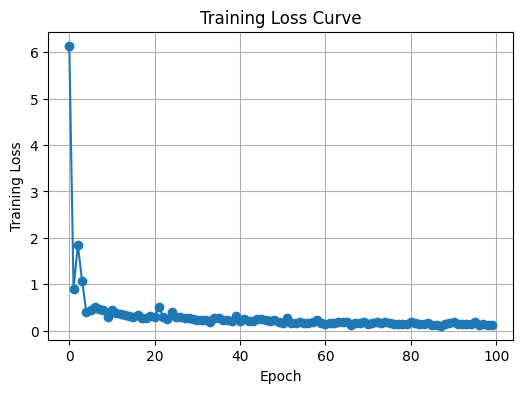

In [18]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, precision_recall_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_mxene.parameters(), lr=pretrained_params['lr'])
batch_size = pretrained_params['batch_size']

epochs = 100
loss_list = []

for epoch in range(epochs):
    model_mxene.train()
    permutation = torch.randperm(X_trainval_t.size(0), generator=torch.Generator().manual_seed(SEED))

    epoch_loss = 0.0
    num_batches = 0

    for i in range(0, X_trainval_t.size(0), batch_size):
        idx = permutation[i:i+batch_size]
        batch_x, batch_y = X_trainval_t[idx], y_trainval_t[idx]

        optimizer.zero_grad()
        outputs = model_mxene(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    loss_list.append(avg_loss)

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

# After training — plot loss curve
plt.figure(figsize=(6,4))
plt.plot(loss_list, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()


Best threshold for MXene model: 0.52
Confusion Matrix:
 [[7 1]
 [0 9]]
Classification Report:
               precision    recall  f1-score   support

         0.0     1.0000    0.8750    0.9333         8
         1.0     0.9000    1.0000    0.9474         9

    accuracy                         0.9412        17
   macro avg     0.9500    0.9375    0.9404        17
weighted avg     0.9471    0.9412    0.9408        17



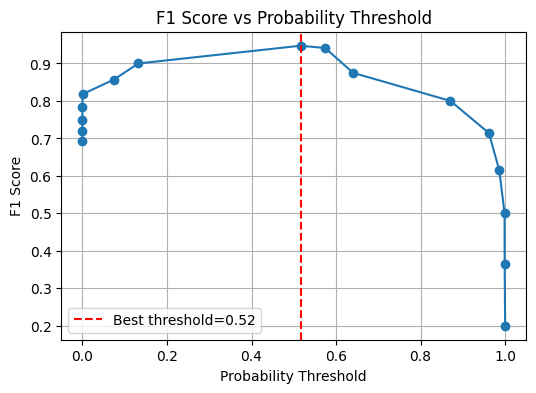


Best threshold for model outputs: 0.52
F1 score on test set: 0.9474


In [19]:
# Evaluate on hold-out test set
model_mxene.eval()
with torch.no_grad():
    outputs = model_mxene(X_test_t).squeeze()
    probs_test = torch.sigmoid(outputs).cpu().numpy()
    y_true_test = y_test_t.cpu().numpy()

precisions, recalls, thresholds = precision_recall_curve(y_true_test, probs_test)

# drop the last element from precision and recall before computing F1
precisions, recalls = precisions[:-1], recalls[:-1]

f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best threshold for MXene model: {best_threshold:.2f}")
y_pred = (probs_test >= best_threshold).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, digits=4))

plt.figure(figsize=(6,4))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_threshold, color='r', linestyle='--', label=f"Best threshold={best_threshold:.2f}")
plt.xlabel("Probability Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Probability Threshold")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nBest threshold for model outputs: {best_threshold:.2f}")
print(f"F1 score on test set: {best_f1:.4f}")

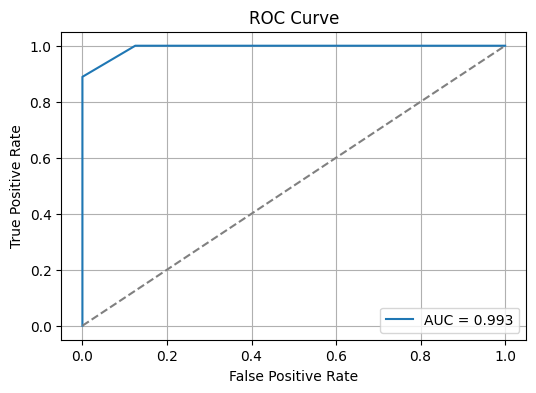

In [20]:
# ROC curve

from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay

fpr, tpr, roc_thresholds = roc_curve(y_true_test, probs_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

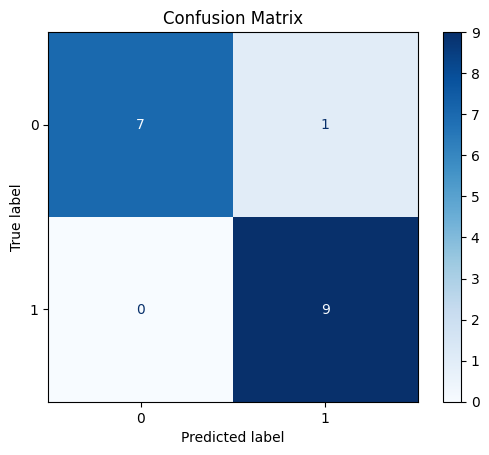

In [21]:
# Confusion matrix
cm = confusion_matrix(y_true_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [22]:
X_mx_solvent_p = mx_solvent_dataset.drop(columns=["label"])
y_mx_solvent_p = mx_solvent_dataset["label"]

X_mx_solvent_unlabeled_p = X_mx_solvent_p[y_mx_solvent_p == 0]


In [23]:
X_mx_solvent_unlabeled_p.head()

,mx,inchikey,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,plasmafrequency_x_1,...,isotope_atom_count,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg,solvent,method_HF,method_LiCl/HF,method_LiF/HCl
83,Ti3C2,ATHHXGZTWNVVOU-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,0,0,1,455.7,760.0,N-methylformamide,True,False,False
84,Ti3C2,ZHNUHDYFZUAESO-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,0,0,1,483.7,760.0,formamide,True,False,False
85,Ti3C2,NNBZCPXTIHJBJL-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,0,0,1,463.2,760.0,"1,2,3,4,4a,5,6,7,8,8a-decahydronaphthalene",True,False,False
86,Ti3C2,HEDRZPFGACZZDS-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,0,0,1,334.3,760.0,chloroform,True,False,False
87,Ti3C2,XDTMQSROBMDMFD-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,0,0,1,353.9,760.0,cyclohexane,True,False,False


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns


/tmp/ipykernel_12967/1155851623.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_mx_solvent_unlabeled['predicted_proba'] = proba_unlabeled
/tmp/ipykernel_12967/1155851623.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_mx_solvent_unlabeled['predicted_label'] = (proba_unlabeled >= 0.5).astype(int)


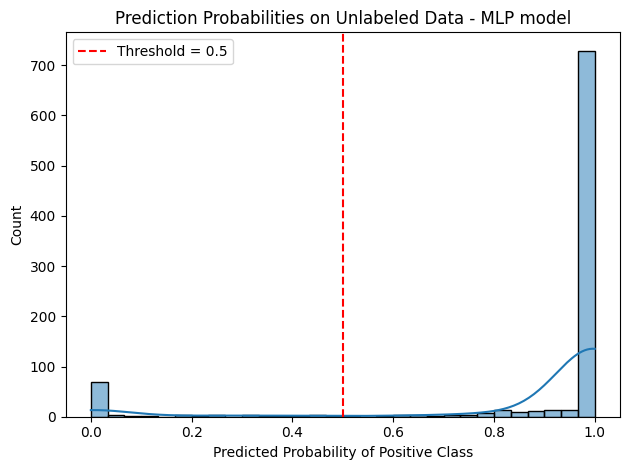

In [25]:

with torch.no_grad():
    # Forward pass
    outputs = model_mxene(torch.tensor(X_mx_solvent_unlabeled_scaled, dtype=torch.float32))

    # If binary classification (single output neuron)
    proba_unlabeled = torch.sigmoid(outputs).cpu().numpy().flatten()

# Add to dataframe
X_mx_solvent_unlabeled['predicted_proba'] = proba_unlabeled
X_mx_solvent_unlabeled['predicted_label'] = (proba_unlabeled >= 0.5).astype(int)

# Plot histogram
sns.histplot(proba_unlabeled, bins=30, kde=True)
plt.axvline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.title("Prediction Probabilities on Unlabeled Data - MLP model")
plt.xlabel("Predicted Probability of Positive Class")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
X_mx_solvent_unlabeled.head()

,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,plasmafrequency_x_1,plasmafrequency_y_1,dyn_stab_1,...,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg,method_HF,method_LiCl/HF,method_LiF/HCl,predicted_proba,predicted_label
83,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0.0,...,0.0,0.0,1.0,455.7,760.0,1.0,0.0,0.0,9.987453e-01,1
84,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0.0,...,0.0,0.0,1.0,483.7,760.0,1.0,0.0,0.0,9.999913e-01,1
85,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0.0,...,0.0,0.0,1.0,463.2,760.0,1.0,0.0,0.0,2.842513e-05,0
86,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0.0,...,0.0,0.0,1.0,334.3,760.0,1.0,0.0,0.0,2.062651e-06,0
87,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0.0,...,0.0,0.0,1.0,353.9,760.0,1.0,0.0,0.0,1.470570e-07,0


In [27]:
feature_names = x_unlabeled.columns
feature_names

Index(['mx', 'label', 'inchikey', 'gap_1', 'work_function_1',
       'formation_energy_1', 'ehull_1', 'alphax_el_1', 'alphay_el_1',
       'alphaz_el_1', 'plasmafrequency_x_1', 'plasmafrequency_y_1',
       'dyn_stab_1', 'has_inversion_symmetry_1', 'dE_zx_1', 'dE_zy_1', 'gap_2',
       'work_function_2', 'formation_energy_2', 'ehull_2', 'alphax_el_2',
       'alphay_el_2', 'alphaz_el_2', 'plasmafrequency_x_2',
       'plasmafrequency_y_2', 'dyn_stab_2', 'has_inversion_symmetry_2',
       'dE_zx_2', 'dE_zy_2', 'gap_3', 'work_function_3', 'formation_energy_3',
       'ehull_3', 'alphax_el_3', 'alphay_el_3', 'alphaz_el_3',
       'plasmafrequency_x_3', 'plasmafrequency_y_3', 'dyn_stab_3',
       'has_inversion_symmetry_3', 'dE_zx_3', 'dE_zy_3', 'delta_d', 'delta_p',
       'delta_h', 'molar_volume', 'molecular_weight', 'xlogp', 'charge',
       'tpsa', 'complexity', 'h_bond_donor_count', 'h_bond_acceptor_count',
       'rotatable_bond_count', 'heavy_atom_count', 'isotope_atom_count',
    

In [28]:
X_mx_solvent_unlabeled.columns

Index(['gap_1', 'work_function_1', 'formation_energy_1', 'ehull_1',
       'alphax_el_1', 'alphay_el_1', 'alphaz_el_1', 'plasmafrequency_x_1',
       'plasmafrequency_y_1', 'dyn_stab_1', 'has_inversion_symmetry_1',
       'dE_zx_1', 'dE_zy_1', 'gap_2', 'work_function_2', 'formation_energy_2',
       'ehull_2', 'alphax_el_2', 'alphay_el_2', 'alphaz_el_2',
       'plasmafrequency_x_2', 'plasmafrequency_y_2', 'dyn_stab_2',
       'has_inversion_symmetry_2', 'dE_zx_2', 'dE_zy_2', 'gap_3',
       'work_function_3', 'formation_energy_3', 'ehull_3', 'alphax_el_3',
       'alphay_el_3', 'alphaz_el_3', 'plasmafrequency_x_3',
       'plasmafrequency_y_3', 'dyn_stab_3', 'has_inversion_symmetry_3',
       'dE_zx_3', 'dE_zy_3', 'delta_d', 'delta_p', 'delta_h', 'molar_volume',
       'molecular_weight', 'xlogp', 'charge', 'tpsa', 'complexity',
       'h_bond_donor_count', 'h_bond_acceptor_count', 'rotatable_bond_count',
       'heavy_atom_count', 'isotope_atom_count', 'atom_stereo_count',
       'bo

In [29]:
unlabeled_proba_threshold = 0.5
high_confidence_pos_idx = np.where(proba_unlabeled > unlabeled_proba_threshold)[0]
print(f"Positive samples above threshold ({unlabeled_proba_threshold}) count: {len(high_confidence_pos_idx)}")

Positive samples above threshold (0.5) count: 817


In [30]:
train_path = f"{drive_path}/master/mxene-solvent-nrc/code-data/training/saved_models/"

In [31]:
import pandas as pd

# Replace with your file path
file_path = f"{train_path}/005_mlp_2d_transfer_mx_prediction.csv"

# Load CSV into DataFrame
df = pd.read_csv(file_path)

In [32]:
df.head()

,Unnamed: 0,mx,inchikey,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,...,covalent_unit_count,boiling_point,mmhg,solvent,method_HF,method_LiCl/HF,method_LiF/HCl,predicted_proba,predicted_label,confidence_bin
0,83,Ti3C2,ATHHXGZTWNVVOU-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,455.7,760.0,N-methylformamide,True,False,False,0.970140,1,Extremely High (>0.9)
1,84,Ti3C2,ZHNUHDYFZUAESO-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,483.7,760.0,formamide,True,False,False,0.992996,1,Extremely High (>0.9)
2,85,Ti3C2,NNBZCPXTIHJBJL-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,463.2,760.0,"1,2,3,4,4a,5,6,7,8,8a-decahydronaphthalene",True,False,False,0.000363,0,Very Low (≤0.1)
3,86,Ti3C2,HEDRZPFGACZZDS-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,334.3,760.0,chloroform,True,False,False,0.000172,0,Very Low (≤0.1)
4,87,Ti3C2,XDTMQSROBMDMFD-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,353.9,760.0,cyclohexane,True,False,False,0.000032,0,Very Low (≤0.1)


In [33]:
df.columns

Index(['Unnamed: 0', 'mx', 'inchikey', 'gap_1', 'work_function_1',
       'formation_energy_1', 'ehull_1', 'alphax_el_1', 'alphay_el_1',
       'alphaz_el_1', 'plasmafrequency_x_1', 'plasmafrequency_y_1',
       'dyn_stab_1', 'has_inversion_symmetry_1', 'dE_zx_1', 'dE_zy_1', 'gap_2',
       'work_function_2', 'formation_energy_2', 'ehull_2', 'alphax_el_2',
       'alphay_el_2', 'alphaz_el_2', 'plasmafrequency_x_2',
       'plasmafrequency_y_2', 'dyn_stab_2', 'has_inversion_symmetry_2',
       'dE_zx_2', 'dE_zy_2', 'gap_3', 'work_function_3', 'formation_energy_3',
       'ehull_3', 'alphax_el_3', 'alphay_el_3', 'alphaz_el_3',
       'plasmafrequency_x_3', 'plasmafrequency_y_3', 'dyn_stab_3',
       'has_inversion_symmetry_3', 'dE_zx_3', 'dE_zy_3', 'delta_d', 'delta_p',
       'delta_h', 'molar_volume', 'molecular_weight', 'xlogp', 'charge',
       'tpsa', 'complexity', 'h_bond_donor_count', 'h_bond_acceptor_count',
       'rotatable_bond_count', 'heavy_atom_count', 'isotope_atom_count',

In [34]:
print(df.index.name)
print(x_unlabeled.index.name)

None
None


In [35]:
df

,Unnamed: 0,mx,inchikey,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,...,covalent_unit_count,boiling_point,mmhg,solvent,method_HF,method_LiCl/HF,method_LiF/HCl,predicted_proba,predicted_label,confidence_bin
0,83,Ti3C2,ATHHXGZTWNVVOU-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,455.7,760.0,N-methylformamide,True,False,False,0.970140,1,Extremely High (>0.9)
1,84,Ti3C2,ZHNUHDYFZUAESO-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,483.7,760.0,formamide,True,False,False,0.992996,1,Extremely High (>0.9)
2,85,Ti3C2,NNBZCPXTIHJBJL-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,463.2,760.0,"1,2,3,4,4a,5,6,7,8,8a-decahydronaphthalene",True,False,False,0.000363,0,Very Low (≤0.1)
3,86,Ti3C2,HEDRZPFGACZZDS-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,334.3,760.0,chloroform,True,False,False,0.000172,0,Very Low (≤0.1)
4,87,Ti3C2,XDTMQSROBMDMFD-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,353.9,760.0,cyclohexane,True,False,False,0.000032,0,Very Low (≤0.1)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
909,992,Ta4C3,BDAGIHXWWSANSR-UHFFFAOYSA-N,0.0,2.395730,-0.881711,0.193120,164.953493,164.953493,2.628653,...,1,373.9,760.0,formic acid,False,True,False,1.000000,1,Extremely High (>0.9)
910,993,Ta4C3,MVPPADPHJFYWMZ-UHFFFAOYSA-N,0.0,2.395730,-0.881711,0.193120,164.953493,164.953493,2.628653,...,1,404.9,760.0,chlorobenzene,False,True,False,1.000000,1,Extremely High (>0.9)
911,994,Ta4C3,AMQJEAYHLZJPGS-UHFFFAOYSA-N,0.0,2.395730,-0.881711,0.193120,164.953493,164.953493,2.628653,...,1,411.0,760.0,pentan-1-ol,False,True,False,1.000000,1,Extremely High (>0.9)
912,995,Ta4C3,YNAVUWVOSKDBBP-UHFFFAOYSA-N,0.0,2.395730,-0.881711,0.193120,164.953493,164.953493,2.628653,...,1,401.6,760.0,morpholine,False,True,False,1.000000,1,Extremely High (>0.9)


In [36]:
x_unlabeled

,mx,label,inchikey,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,...,isotope_atom_count,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg,solvent,method_HF,method_LiCl/HF,method_LiF/HCl
83,Ti3C2,0,ATHHXGZTWNVVOU-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,455.7,760.0,N-methylformamide,True,False,False
84,Ti3C2,0,ZHNUHDYFZUAESO-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,483.7,760.0,formamide,True,False,False
85,Ti3C2,0,NNBZCPXTIHJBJL-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,463.2,760.0,"1,2,3,4,4a,5,6,7,8,8a-decahydronaphthalene",True,False,False
86,Ti3C2,0,HEDRZPFGACZZDS-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,334.3,760.0,chloroform,True,False,False
87,Ti3C2,0,XDTMQSROBMDMFD-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,353.9,760.0,cyclohexane,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,Ta4C3,0,BDAGIHXWWSANSR-UHFFFAOYSA-N,0.0,2.395730,-0.881711,0.193120,164.953493,164.953493,2.628653,...,0,0,0,1,373.9,760.0,formic acid,False,True,False
993,Ta4C3,0,MVPPADPHJFYWMZ-UHFFFAOYSA-N,0.0,2.395730,-0.881711,0.193120,164.953493,164.953493,2.628653,...,0,0,0,1,404.9,760.0,chlorobenzene,False,True,False
994,Ta4C3,0,AMQJEAYHLZJPGS-UHFFFAOYSA-N,0.0,2.395730,-0.881711,0.193120,164.953493,164.953493,2.628653,...,0,0,0,1,411.0,760.0,pentan-1-ol,False,True,False
995,Ta4C3,0,YNAVUWVOSKDBBP-UHFFFAOYSA-N,0.0,2.395730,-0.881711,0.193120,164.953493,164.953493,2.628653,...,0,0,0,1,401.6,760.0,morpholine,False,True,False


In [37]:
x_lookup = x_unlabeled[
    ["inchikey", "mx", "solvent"]
].drop_duplicates(subset="inchikey")

X_mx_solvent_unlabeled = df.merge(
    x_lookup,
    on="inchikey",
    how="left"
)

print(len(X_mx_solvent_unlabeled))

914


In [38]:
X_mx_solvent_unlabeled

,Unnamed: 0,mx_x,inchikey,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,...,mmhg,solvent_x,method_HF,method_LiCl/HF,method_LiF/HCl,predicted_proba,predicted_label,confidence_bin,mx_y,solvent_y
0,83,Ti3C2,ATHHXGZTWNVVOU-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,760.0,N-methylformamide,True,False,False,0.970140,1,Extremely High (>0.9),Ti3C2,N-methylformamide
1,84,Ti3C2,ZHNUHDYFZUAESO-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,760.0,formamide,True,False,False,0.992996,1,Extremely High (>0.9),Ti3C2,formamide
2,85,Ti3C2,NNBZCPXTIHJBJL-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,760.0,"1,2,3,4,4a,5,6,7,8,8a-decahydronaphthalene",True,False,False,0.000363,0,Very Low (≤0.1),Ti3C2,"1,2,3,4,4a,5,6,7,8,8a-decahydronaphthalene"
3,86,Ti3C2,HEDRZPFGACZZDS-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,760.0,chloroform,True,False,False,0.000172,0,Very Low (≤0.1),Ti3C2,chloroform
4,87,Ti3C2,XDTMQSROBMDMFD-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,760.0,cyclohexane,True,False,False,0.000032,0,Very Low (≤0.1),Ti3C2,cyclohexane
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
909,992,Ta4C3,BDAGIHXWWSANSR-UHFFFAOYSA-N,0.0,2.395730,-0.881711,0.193120,164.953493,164.953493,2.628653,...,760.0,formic acid,False,True,False,1.000000,1,Extremely High (>0.9),Ti3C2,formic acid
910,993,Ta4C3,MVPPADPHJFYWMZ-UHFFFAOYSA-N,0.0,2.395730,-0.881711,0.193120,164.953493,164.953493,2.628653,...,760.0,chlorobenzene,False,True,False,1.000000,1,Extremely High (>0.9),Ti3C2,chlorobenzene
911,994,Ta4C3,AMQJEAYHLZJPGS-UHFFFAOYSA-N,0.0,2.395730,-0.881711,0.193120,164.953493,164.953493,2.628653,...,760.0,pentan-1-ol,False,True,False,1.000000,1,Extremely High (>0.9),Ti3C2,pentan-1-ol
912,995,Ta4C3,YNAVUWVOSKDBBP-UHFFFAOYSA-N,0.0,2.395730,-0.881711,0.193120,164.953493,164.953493,2.628653,...,760.0,morpholine,False,True,False,1.000000,1,Extremely High (>0.9),Ti3C2,morpholine


In [39]:
high_conf = X_mx_solvent_unlabeled[X_mx_solvent_unlabeled['predicted_proba'] >= 0.9]
high_conf = high_conf[high_conf['predicted_proba'] < 0.99]
top_list = high_conf.sort_values(by='predicted_proba', ascending=False)
print(top_list.shape)
top_list[['solvent_x', 'mx_x','predicted_proba', 'method_HF', 'method_LiCl/HF',
       'method_LiF/HCl']].head(10)

(83, 70)


,solvent_x,mx_x,predicted_proba,method_HF,method_LiCl/HF,method_LiF/HCl
179,chlorobenzene,Nb2C1,0.989468,False,True,False
156,"1,2,3,4,4a,5,6,7,8,8a-decahydronaphthalene",Nb2C1,0.989317,False,True,False
89,NaN,Nb2C1,0.989274,True,False,False
621,oxolan-2-one,Zr3C2,0.988765,False,False,True
257,1-(2-butoxyethoxy)butane,V2C1,0.988597,False,False,True
251,propan-1-ol,V2C1,0.988243,False,False,True
224,ethanol,V2C1,0.988132,False,False,True
282,propan-2-ol,V2C1,0.987897,False,True,False
588,oxidane,Zr3C2,0.987803,False,False,True
101,styrene,Nb2C1,0.987524,True,False,False


In [40]:
print("\n=== Summary of predicted probabilities on unlabeled data ===")
print(X_mx_solvent_unlabeled['predicted_proba'].describe())

# Count how many samples fall into different confidence zones
bins = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
labels = ['Very Low (≤0.1)', 'Low (0.1–0.3)', 'Mid (0.3–0.5)',
          'High (0.5–0.7)', 'Very High (0.7–0.9)', 'Extremely High (>0.9)']

X_mx_solvent_unlabeled['confidence_bin'] = pd.cut(X_mx_solvent_unlabeled['predicted_proba'], bins=bins, labels=labels, include_lowest=True)
print("\n=== Prediction count by confidence bin ===")
print(X_mx_solvent_unlabeled['confidence_bin'].value_counts().sort_index())


=== Summary of predicted probabilities on unlabeled data ===
count    914.000000
mean       0.854495
std        0.310305
min        0.000015
25%        0.959975
50%        1.000000
75%        1.000000
max        1.000000
Name: predicted_proba, dtype: float64

=== Prediction count by confidence bin ===
confidence_bin
Very Low (≤0.1)           81
Low (0.1–0.3)             20
Mid (0.3–0.5)             23
High (0.5–0.7)            34
Very High (0.7–0.9)       33
Extremely High (>0.9)    723
Name: count, dtype: int64


In [41]:
X_mx_solvent_unlabeled.to_csv(f"{train_path}/005_mlp_2d_transfer_mx_prediction.csv")
X_mx_solvent_unlabeled.to_pickle(f"{train_path}/005__mlp_2d_transfer_mx_prediction.pkl")

In [42]:
unwanted = ['mx', 'inchikey', 'solvent', 'predicted_proba', 'predicted_label', 'confidence_bin', 'label']   # replace with the names you don't want
feature_names = [f for f in feature_names if f not in unwanted]

print(feature_names)

['gap_1', 'work_function_1', 'formation_energy_1', 'ehull_1', 'alphax_el_1', 'alphay_el_1', 'alphaz_el_1', 'plasmafrequency_x_1', 'plasmafrequency_y_1', 'dyn_stab_1', 'has_inversion_symmetry_1', 'dE_zx_1', 'dE_zy_1', 'gap_2', 'work_function_2', 'formation_energy_2', 'ehull_2', 'alphax_el_2', 'alphay_el_2', 'alphaz_el_2', 'plasmafrequency_x_2', 'plasmafrequency_y_2', 'dyn_stab_2', 'has_inversion_symmetry_2', 'dE_zx_2', 'dE_zy_2', 'gap_3', 'work_function_3', 'formation_energy_3', 'ehull_3', 'alphax_el_3', 'alphay_el_3', 'alphaz_el_3', 'plasmafrequency_x_3', 'plasmafrequency_y_3', 'dyn_stab_3', 'has_inversion_symmetry_3', 'dE_zx_3', 'dE_zy_3', 'delta_d', 'delta_p', 'delta_h', 'molar_volume', 'molecular_weight', 'xlogp', 'charge', 'tpsa', 'complexity', 'h_bond_donor_count', 'h_bond_acceptor_count', 'rotatable_bond_count', 'heavy_atom_count', 'isotope_atom_count', 'atom_stereo_count', 'bond_stereo_count', 'covalent_unit_count', 'boiling_point', 'mmhg', 'method_HF', 'method_LiCl/HF', 'method

61
61
                feature  importance
17          alphax_el_2    0.151655
2    formation_energy_1    0.145243
14      work_function_2    0.128402
9            dyn_stab_1    0.121210
1       work_function_1    0.115396
5           alphay_el_1    0.098535
59       method_LiCl/HF    0.097653
8   plasmafrequency_y_1    0.088993
0                 gap_1    0.087776
7   plasmafrequency_x_1    0.085323


/tmp/ipykernel_12967/1418772143.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature',


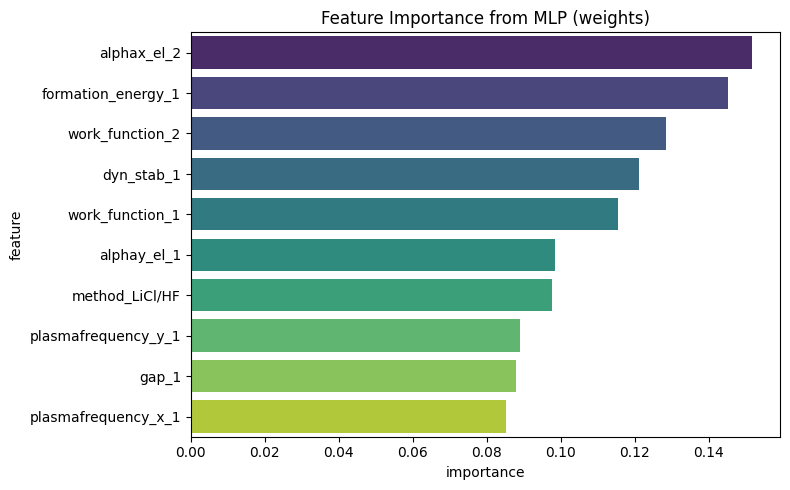

In [43]:
from sklearn.inspection import permutation_importance

first_layer_weights = model_mxene.fc1.weight.detach().cpu().numpy()

# Take mean absolute weight per input feature
importance = np.mean(np.abs(first_layer_weights), axis=0)
print(len(importance))
print(len(feature_names))

# Build dataframe
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(10))

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature',
            data=feature_importance_df.head(10),
            palette='viridis')
plt.title('Feature Importance from MLP (weights)')
plt.tight_layout()
plt.show()

In [44]:
mx_features = ['gap_1', 'work_function_1', 'formation_energy_1',
       'ehull_1', 'alphax_el_1', 'alphay_el_1', 'alphaz_el_1',
       'plasmafrequency_x_1', 'plasmafrequency_y_1', 'dyn_stab_1',
       'has_inversion_symmetry_1', 'dE_zx_1', 'dE_zy_1', 'gap_2',
       'work_function_2', 'formation_energy_2', 'ehull_2', 'alphax_el_2',
       'alphay_el_2', 'alphaz_el_2', 'plasmafrequency_x_2',
       'plasmafrequency_y_2', 'dyn_stab_2', 'has_inversion_symmetry_2',
       'dE_zx_2', 'dE_zy_2', 'gap_3', 'work_function_3', 'formation_energy_3',
       'ehull_3', 'alphax_el_3', 'alphay_el_3', 'alphaz_el_3',
       'plasmafrequency_x_3', 'plasmafrequency_y_3', 'dyn_stab_3',
       'has_inversion_symmetry_3', 'dE_zx_3', 'dE_zy_3']
solv_features = ['delta_d', 'delta_p',
       'delta_h', 'molar_volume', 'molecular_weight', 'xlogp', 'charge',
       'tpsa', 'complexity', 'h_bond_donor_count', 'h_bond_acceptor_count',
       'rotatable_bond_count', 'heavy_atom_count', 'isotope_atom_count',
       'atom_stereo_count', 'bond_stereo_count', 'covalent_unit_count',
       'boiling_point', 'mmhg']

In [45]:
top_mx = feature_importance_df[feature_importance_df['feature'].isin(mx_features)] \
            .sort_values(by='importance', ascending=False) \
            .head(5)

# Top 5 from Solvent features
top_solv = feature_importance_df[feature_importance_df['feature'].isin(solv_features)] \
              .sort_values(by='importance', ascending=False) \
              .head(5)

# Display
print("Total  MXene Features:", len(mx_features))
print("Top 5 MXene Features:")
print(top_mx.to_string(index=False))

print("\nTotal  Solvent Features:", len(solv_features))
print("Top 5 Solvent Features:")
print(top_solv.to_string(index=False))

Total  MXene Features: 39
Top 5 MXene Features:
           feature  importance
       alphax_el_2    0.151655
formation_energy_1    0.145243
   work_function_2    0.128402
        dyn_stab_1    0.121210
   work_function_1    0.115396

Total  Solvent Features: 19
Top 5 Solvent Features:
            feature  importance
covalent_unit_count    0.076914
            delta_d    0.073789
 h_bond_donor_count    0.073501
            delta_h    0.071808
       molar_volume    0.070767


In [46]:
df = df[df["predicted_proba"] <= 0.999]

In [47]:
import pandas as pd

# Assuming df has columns: ['mx', 'solvent', 'probability']
top_solvents = (
    df.loc[df.groupby("mx")["predicted_proba"].idxmax(), ["mx", "solvent", "predicted_proba"]]
    .reset_index(drop=True)
)


In [48]:
top_solvents

,mx,solvent,predicted_proba
0,Nb2C1,pyridine,0.998841
1,Ti3C2,2-(2-hydroxyethoxy)ethanol,0.998884
2,V2C1,decan-1-ol,0.998996
3,Zr3C2,formamide,0.998658


In [49]:
top_solvents = (
    df.sort_values(
        ["mx", "predicted_proba"],
        ascending=[True, False]
    )
    .groupby("mx")
    .head(5)
    [["mx", "solvent", "predicted_proba", "method_HF",	"method_LiCl/HF",	"method_LiF/HCl"]]
    .reset_index(drop=True)
)

print(top_solvents)

       mx                      solvent  predicted_proba  method_HF  \
0   Nb2C1                     pyridine         0.998841       True   
1   Nb2C1                ethyl acetate         0.998538      False   
2   Nb2C1          1,2-dichlorobenzene         0.998453      False   
3   Nb2C1                ethyl acetate         0.998077       True   
4   Nb2C1                 propan-2-one         0.997746      False   
5   Ti3C2   2-(2-hydroxyethoxy)ethanol         0.998884       True   
6   Ti3C2  4-methyl-1,3-dioxolan-2-one         0.998549      False   
7   Ti3C2                    formamide         0.996926      False   
8   Ti3C2                    formamide         0.992996       True   
9   Ti3C2                 oxolan-2-one         0.987245      False   
10   V2C1                   decan-1-ol         0.998996      False   
11   V2C1     1-methylpyrrolidin-2-one         0.998972       True   
12   V2C1        N,N-dimethylacetamide         0.998550      False   
13   V2C1        N,N

In [50]:
model_mxene.eval()

with torch.no_grad():

    X_train_tensor = torch.tensor(
        X_mx_solvent_labeled_scaled.astype(np.float32),
        dtype=torch.float32
    )

    outputs = model_mxene(X_train_tensor)

    train_proba = (
        torch.sigmoid(outputs)
        .cpu()
        .numpy()
        .flatten()
    )

# add to dataframe if desired
x_labeled["predicted_proba"] = train_proba
x_labeled["predicted_label"] = (
    train_proba >= 0.5
).astype(int)

/tmp/ipykernel_12967/2520434413.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_labeled["predicted_proba"] = train_proba
/tmp/ipykernel_12967/2520434413.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_labeled["predicted_label"] = (


In [51]:
x_labeled

,mx,label,inchikey,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,...,bond_stereo_count,covalent_unit_count,boiling_point,mmhg,solvent,method_HF,method_LiCl/HF,method_LiF/HCl,predicted_proba,predicted_label
0,Ti3C2,1,XLYOFNOQVPJJNP-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,1,373.2,760.0,oxidane,True,False,False,0.985629,1
1,Ti3C2,1,LFQSCWFLJHTTHZ-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,1,351.5,760.0,ethanol,True,False,False,0.640355,1
2,Ti3C2,-1,OKKJLVBELUTLKV-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,1,337.8,760.0,methanol,True,False,False,0.675357,1
3,Ti3C2,-1,CSCPPACGZOOCGX-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,1,329.3,760.0,propan-2-one,True,False,False,0.033670,0
4,Ti3C2,-1,WEVYAHXRMPXWCK-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,1,354.8,760.0,acetonitrile,True,False,False,0.385452,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,Ti3C2,-1,MVPPADPHJFYWMZ-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,1,404.9,760.0,chlorobenzene,False,False,True,0.000129,0
79,Ti3C2,1,AMQJEAYHLZJPGS-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,1,411.0,760.0,pentan-1-ol,False,False,True,0.711568,1
80,Ti3C2,-1,YNAVUWVOSKDBBP-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,1,401.6,760.0,morpholine,False,False,True,0.771026,1
81,Ti3C2,1,RUOJZAUFBMNUDX-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,1,513.2,760.0,"4-methyl-1,3-dioxolan-2-one",False,False,True,0.999994,1


In [52]:
top_solvents = (
    x_labeled
    .sort_values(
        ["mx", "predicted_proba"],
        ascending=[True, False]
    )
    .drop_duplicates(["mx", "solvent"])
    .groupby("mx")
    .head(5)
    [["mx", "solvent", "predicted_proba", "method_HF",	"method_LiCl/HF",	"method_LiF/HCl"]]
    .reset_index(drop=True)
)

print(top_solvents)

       mx                      solvent  predicted_proba  method_HF  \
0   Mo2C1                      oxidane         1.000000       True   
1   Nb2C1     1-methylpyrrolidin-2-one         1.000000       True   
2   Ta4C3                      ethanol         1.000000       True   
3   Ti2C1        methylsulfinylmethane         1.000000      False   
4   Ti3C2  4-methyl-1,3-dioxolan-2-one         0.999994      False   
5   Ti3C2                    formamide         0.999993      False   
6   Ti3C2   2-(2-hydroxyethoxy)ethanol         0.999950      False   
7   Ti3C2            N-methylformamide         0.998865      False   
8   Ti3C2                 oxolan-2-one         0.998653      False   
9    V2C1     1-methylpyrrolidin-2-one         1.000000      False   
10   V2C1                     methanol         0.999933       True   
11   V4C3     1-methylpyrrolidin-2-one         1.000000       True   
12  Zr3C2                      ethanol         0.803965       True   

    method_LiCl/HF 

In [53]:
top_solvents = (
    x_labeled[
        x_labeled["predicted_proba"] < 0.999
    ]
    .sort_values(
        ["mx", "predicted_proba"],
        ascending=[True, False]
    )
    .drop_duplicates(["mx", "solvent"])
    .groupby("mx")
    .head(5)
    [["mx", "solvent", "predicted_proba"]]
    .reset_index(drop=True)
)

print(top_solvents)

      mx                   solvent  predicted_proba
0  Ti3C2         N-methylformamide         0.998865
1  Ti3C2              oxolan-2-one         0.998653
2  Ti3C2     methylsulfinylmethane         0.998625
3  Ti3C2                   oxidane         0.996204
4  Ti3C2  1-methylpyrrolidin-2-one         0.994550
5  Zr3C2                   ethanol         0.803965
